# Loan Default Prediction — ML Pipeline

**Dataset**: Loan_Default.csv (148,670 rows, 34 features)  
**Target**: `Status` (0 = No Default, 1 = Default)  
**Class ratio**: 75.4% No Default / 24.6% Default (mild imbalance, 3:1)  

## Key findings from EDA that shaped this pipeline:
- 6 columns confirmed as **post-default recorded** (data leakage) and dropped
- Missing value patterns for several features perfectly correlated with default status
- Only `dtir1` and `income` had genuine MNAR signal worth retaining as indicator flags
- `credit_type` had EQUI category with 99.99% default rate — confirmed leakage

## Columns dropped and reasons:
| Column | Reason |
|--------|--------|
| `interest_rate_spread` | Structural issue — zero for all defaulters |
| `credit_type` | EQUI category = confirmed leakage |
| `ltv` | Derived from loan_amount and property_value, high VIF |
| `upfront_charges` | 99.6% missing for defaulters — post-default recorded |
| `rate_of_interest` | 99.5% missing for defaulters — post-default recorded |
| `property_value` | 40.9% missing for defaulters — post-default recorded |

## Final Results:
| Model | ROC-AUC | PR-AUC |
|-------|---------|--------|
| XGBoost | 0.876 | 0.800 |
| Logistic Regression | 0.754 | 0.554 |

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix,
                             RocCurveDisplay, PrecisionRecallDisplay)
from xgboost import XGBClassifier

## 2. Load Data

In [2]:
df = pd.read_csv('Loan_Default.csv')
print(df.shape)
df.head()

(148670, 34)


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


## 3. Train-Test Split

Split is done **before any preprocessing** to prevent data leakage.  
Imputers, scalers, and encoders are fitted only on `X_train` and applied to `X_test`.  
`stratify=y` preserves the class ratio in both sets.

In [3]:
X = df.drop(columns=['Status'])
y = df['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train shape: {X_train.shape}')
print(f'Test shape : {X_test.shape}')
print(f'\nClass ratio in train:')
print(y_train.value_counts(normalize=True).round(3))

Train shape: (118936, 33)
Test shape : (29734, 33)

Class ratio in train:
Status
0    0.754
1    0.246
Name: proportion, dtype: float64


## 4. Stage 1 — Data Cleaning

- Lowercase all column names and object values for consistency
- Drop confirmed leakage columns and non-predictive identifiers

**Note**: `rate_of_interest`, `upfront_charges`, `property_value` are dropped because  
they were missing for 99.5%, 99.6%, and 40.9% of defaulters respectively —  
confirmed post-default recorded fields that would cause leakage.

In [4]:
def lowercase_columns(X, y=None):
    X = X.copy()
    X.columns = X.columns.str.lower()                          # lowercase column names
    object_col = X.select_dtypes(include='object').columns
    for col in object_col:
        X[col] = X[col].str.lower()                            # lowercase values
    return X

lowercase_step = FunctionTransformer(lowercase_columns)


def dropcol(X, y=None):
    X = X.copy()
    X.drop(columns=[
        'interest_rate_spread',   # structural issue — zero for all defaulters
        'credit_type',            # EQUI category = 99.99% default rate — confirmed leakage
        'ltv',                    # derived from loan_amount and property_value, high VIF
        'upfront_charges',        # 99.6% missing for defaulters — post-default recorded
        'rate_of_interest',       # 99.5% missing for defaulters — post-default recorded
        'property_value',         # 40.9% missing for defaulters — post-default recorded
    ], inplace=True, errors='ignore')
    return X

dropcol_step = FunctionTransformer(dropcol)

## 5. Stage 2 — Missing Value Imputation

Missing values classified by type from EDA:

| Column | Type | Treatment | Indicator flag |
|--------|------|-----------|----------------|
| `income` | MNAR | Median fill | Yes — 3.4% vs 7.1% (genuine signal) |
| `dtir1` | MNAR | Median fill | No — 44.3% vs 7.0% (too skewed, removed) |
| `age` | MNAR | Mode fill | No — 100% default when missing (leakage) |
| `submission_of_application` | MNAR | Mode fill | No — 100% default when missing (leakage) |
| `loan_limit`, `neg_ammortization`, `loan_purpose`, `term`, `approv_in_adv` | MCAR | Mode fill | No |

In [5]:
mnar_num_with_flag    = ['income']
mnar_num_without_flag = ['dtir1']
mnar_cat_without_flag = ['age', 'submission_of_application']
mcar_cols             = ['loan_limit', 'neg_ammortization', 'loan_purpose', 'term', 'approv_in_adv']

imputer = ColumnTransformer(
    transformers=[
        ('mnar_flag',   SimpleImputer(strategy='median',        add_indicator=True),  mnar_num_with_flag),
        ('mnar_noflag', SimpleImputer(strategy='median',        add_indicator=False), mnar_num_without_flag),
        ('mnar_cat',    SimpleImputer(strategy='most_frequent', add_indicator=False), mnar_cat_without_flag),
        ('mcar',        SimpleImputer(strategy='most_frequent'),                      mcar_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

## 6. Stage 3 — Feature Engineering

- **Yeo-Johnson transform**: applied to skewed numerical columns (`income`, `loan_amount`, `term`)
- **Rare label grouping**: categories with < 1% frequency grouped into meaningful buckets

**Note**: `high_ir_segment` flag (rate_of_interest > 5.5%) was removed because  
`rate_of_interest` itself was dropped as a leakage column.

In [6]:
# Yeo-Johnson transform on skewed columns
yeo_cols = ['income', 'loan_amount', 'term']

yeo_step = ColumnTransformer(
    transformers=[('yeo', PowerTransformer(method='yeo-johnson'), yeo_cols)],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')


# Rare label grouping
# opc < 1% in open_credit → 'other'
# 2u/3u/4u in total_units → 'multi_unit'
rare_label_mapping = {
    'open_credit' : {'opc': 'other'},
    'total_units' : {'2u': 'multi_unit', '3u': 'multi_unit', '4u': 'multi_unit'}
}

def group_rare_labels(X, y=None):
    X = X.copy()
    for col, mapping in rare_label_mapping.items():
        if col in X.columns:
            X[col] = X[col].replace(mapping)
    return X

rare_label_step = FunctionTransformer(group_rare_labels)

## 7. Stage 4 — Feature Selection

Dropping columns based on collinearity analysis from EDA:

| Column | Reason |
|--------|--------|
| `id`, `year` | Non-predictive identifiers |
| `business_or_commercial` | High collinearity with `loan_type` (weaker predictor) |
| `construction_type` | High collinearity with `security_type`, negligible signal |
| `secured_by` | Cramer's V = 0.98 with `security_type` |

In [7]:
cols_to_drop = [
    'id',                      # non-predictive identifier
    'year',                    # non-predictive identifier
    'business_or_commercial',  # high collinearity with loan_type
    'construction_type',       # high collinearity with security_type
    'secured_by',              # Cramer's V = 0.98 with security_type
]

def drop_features(X, y=None):
    X = X.copy()
    cols = [col for col in cols_to_drop if col in X.columns]
    X.drop(columns=cols, inplace=True)
    return X

feature_selection_step = FunctionTransformer(drop_features)

## 8. Stage 5 — Encoding

- **OrdinalEncoder**: `age` (ordered categories — must preserve order)
- **OneHotEncoder**: all other categorical columns
  - `handle_unknown='ignore'` — unseen categories encoded as all zeros
  - `drop='first'` — avoids dummy variable trap

In [8]:
age_order    = ['<25', '25-34', '35-44', '45-54', '55-64', '65-74', '>74']
ordinal_cols = ['age']
ohe_cols     = [
    'loan_limit', 'approv_in_adv', 'loan_type', 'loan_purpose',
    'neg_ammortization', 'interest_only', 'lump_sum_payment',
    'open_credit', 'total_units', 'security_type',
    'submission_of_application', 'region', 'gender',
    'co-applicant_credit_type', 'occupancy_type', 'credit_worthiness'
]

encoding_step = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(
            categories=[age_order],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), ordinal_cols),
        ('ohe', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False,
            drop='first'
        ), ohe_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

## 9. Stage 6 — Scaling

Scaler assigned per column based on residual outlier analysis after Yeo-Johnson:

| Column | Outlier % | Skew | Scaler |
|--------|-----------|------|--------|
| `income` | 3.19% | 0.49 | StandardScaler |
| `loan_amount` | 0.42% | -0.01 | StandardScaler |
| `dtir1` | 3.71% | -0.66 | StandardScaler |
| `credit_score` | 0.00% | 0.00 | StandardScaler |
| `term` | 18.16% | -1.73 | RobustScaler |

In [9]:
standard_cols = ['income', 'loan_amount', 'dtir1', 'credit_score']
robust_cols   = ['term']

scaler_step = ColumnTransformer(
    transformers=[
        ('standard', StandardScaler(), standard_cols),
        ('robust',   RobustScaler(),   robust_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

## 10. Cast Step

Missingness indicator columns produced by `SimpleImputer(add_indicator=True)` are  
stored as boolean by default. Casting to float ensures compatibility with  
downstream transformers (PowerTransformer, scalers) that expect numeric input.

In [10]:
def cast_indicators_to_float(X, y=None):
    X = X.copy()
    indicator_cols = [c for c in X.columns if 'missingindicator' in c.lower()]
    X[indicator_cols] = X[indicator_cols].astype(float)
    return X

cast_step = FunctionTransformer(cast_indicators_to_float)

## 11. Assemble Full Pipeline

All preprocessing steps chained in order.  
Pipeline ensures no leakage — `fit()` on train, `transform()` on test every time.

In [11]:
preprocessing_pipeline = Pipeline([
    ('lowercase',         lowercase_step),          # Stage 1a — fix casing
    ('drop_cols',         dropcol_step),             # Stage 1b — drop leakage + derived cols
    ('imputer',           imputer),                  # Stage 2  — missing value imputation
    ('cast_float',        cast_step),                # Stage 2b — cast indicators to float
    ('rare_labels',       rare_label_step),          # Stage 3a — group rare categories
    ('yeo',               yeo_step),                 # Stage 3b — Yeo-Johnson transform
    ('feature_selection', feature_selection_step),   # Stage 4  — drop collinear features
    ('encoding',          encoding_step),            # Stage 5  — encode categoricals
    ('scaling',           scaler_step),              # Stage 6  — scale numericals
])

# Verify pipeline runs cleanly
X_transformed = preprocessing_pipeline.fit_transform(X_train)
print(f'Output shape  : {X_transformed.shape}')
print(f'Missing values: {X_transformed.isnull().sum().sum()}')
print(f'\nFinal features:')
for i, col in enumerate(X_transformed.columns):
    print(f'  {i:2d}. {col}')

Output shape  : (118936, 31)
Missing values: 0

Final features:
   0. income
   1. loan_amount
   2. dtir1
   3. credit_score
   4. term
   5. age
   6. loan_limit_ncf
   7. approv_in_adv_pre
   8. loan_type_type2
   9. loan_type_type3
  10. loan_purpose_p2
  11. loan_purpose_p3
  12. loan_purpose_p4
  13. neg_ammortization_not_neg
  14. interest_only_not_int
  15. lump_sum_payment_not_lpsm
  16. open_credit_other
  17. total_units_multi_unit
  18. security_type_indriect
  19. submission_of_application_to_inst
  20. region_north
  21. region_north-east
  22. region_south
  23. gender_joint
  24. gender_male
  25. gender_sex not available
  26. co-applicant_credit_type_exp
  27. occupancy_type_pr
  28. occupancy_type_sr
  29. credit_worthiness_l2
  30. missingindicator_income


## 12. Model Training & Cross-Validation

- **Class imbalance**: 3:1 ratio — handled via `class_weight='balanced'` (no SMOTE needed)
- **CV strategy**: StratifiedKFold (k=5) — preserves class ratio across folds
- **Metrics**: ROC-AUC and PR-AUC — accuracy is misleading for imbalanced data
- `X_train` passed raw — pipeline preprocesses internally on each fold (no leakage)

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'roc_auc' : 'roc_auc',
    'pr_auc'  : 'average_precision'
}

models = {
    'Logistic Regression': LogisticRegression(
                               class_weight='balanced',
                               max_iter=1000,
                               random_state=42
                           ),
    'XGBoost'            : XGBClassifier(
                               scale_pos_weight=89625/29311,
                               random_state=42,
                               eval_metric='auc',
                               verbosity=0
                           ),
}

results = []

for model_name, model in models.items():
    full_pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model',         model)
    ])

    cv_results = cross_validate(
        full_pipeline, X_train, y_train,
        cv=cv, scoring=scoring,
        return_train_score=False
    )

    results.append({
        'model'        : model_name,
        'roc_auc_mean' : cv_results['test_roc_auc'].mean().round(4),
        'roc_auc_std'  : cv_results['test_roc_auc'].std().round(4),
        'pr_auc_mean'  : cv_results['test_pr_auc'].mean().round(4),
        'pr_auc_std'   : cv_results['test_pr_auc'].std().round(4),
    })
    print(f'{model_name} done.')

results_df = pd.DataFrame(results).sort_values('roc_auc_mean', ascending=False)
print('\nCV Results:')
print(results_df)

Logistic Regression done.
XGBoost done.

CV Results:
                 model  roc_auc_mean  roc_auc_std  pr_auc_mean  pr_auc_std
1              XGBoost        0.8663       0.0032       0.7845      0.0038
0  Logistic Regression        0.7536       0.0030       0.5538      0.0025


## 13. Final Test Set Evaluation

Test set used **only once** — after model selection based on CV results.  
This gives an honest estimate of real-world performance on unseen data.

In [13]:
best_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', XGBClassifier(
                 scale_pos_weight=89625/29311,
                 random_state=42,
                 eval_metric='auc',
                 verbosity=0
             ))
])

best_pipeline.fit(X_train, y_train)

y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]
y_pred       = best_pipeline.predict(X_test)

print('=== Final Test Set Evaluation ===\n')
print(f'ROC-AUC : {roc_auc_score(y_test, y_pred_proba):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_pred_proba):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

=== Final Test Set Evaluation ===

ROC-AUC : 0.8756
PR-AUC  : 0.8002

Classification Report:
              precision    recall  f1-score   support

  No Default       0.90      0.90      0.90     22406
     Default       0.69      0.71      0.70      7328

    accuracy                           0.85     29734
   macro avg       0.80      0.80      0.80     29734
weighted avg       0.85      0.85      0.85     29734

Confusion Matrix:
[[20120  2286]
 [ 2144  5184]]


## 14. Evaluation Plots

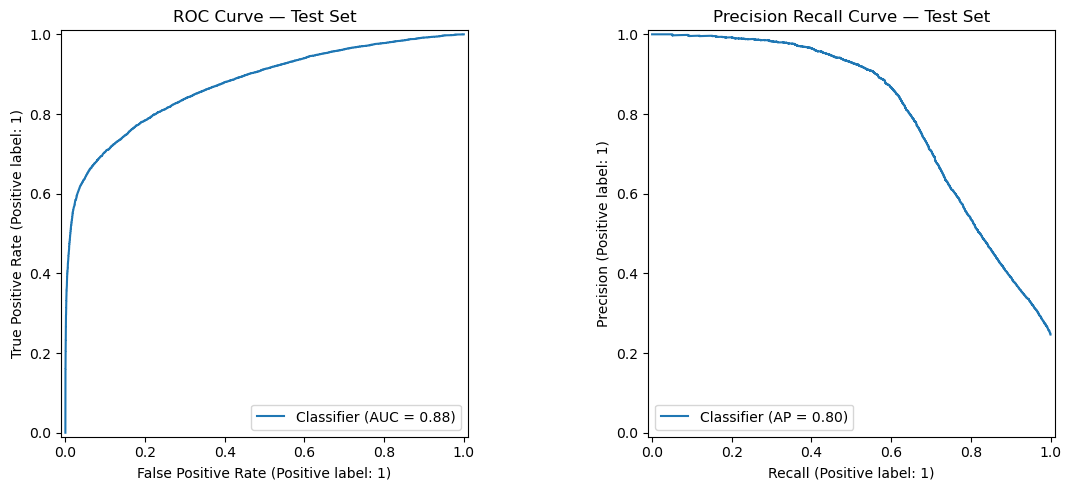

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0])
axes[0].set_title('ROC Curve — Test Set')

PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1])
axes[1].set_title('Precision Recall Curve — Test Set')

plt.tight_layout()
plt.show()

## 15. Feature Importance (XGBoost)

/var/folders/8m/v0ym2x895jn0544k3r1j107c0000gn/T/ipykernel_6715/3195916560.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='viridis')


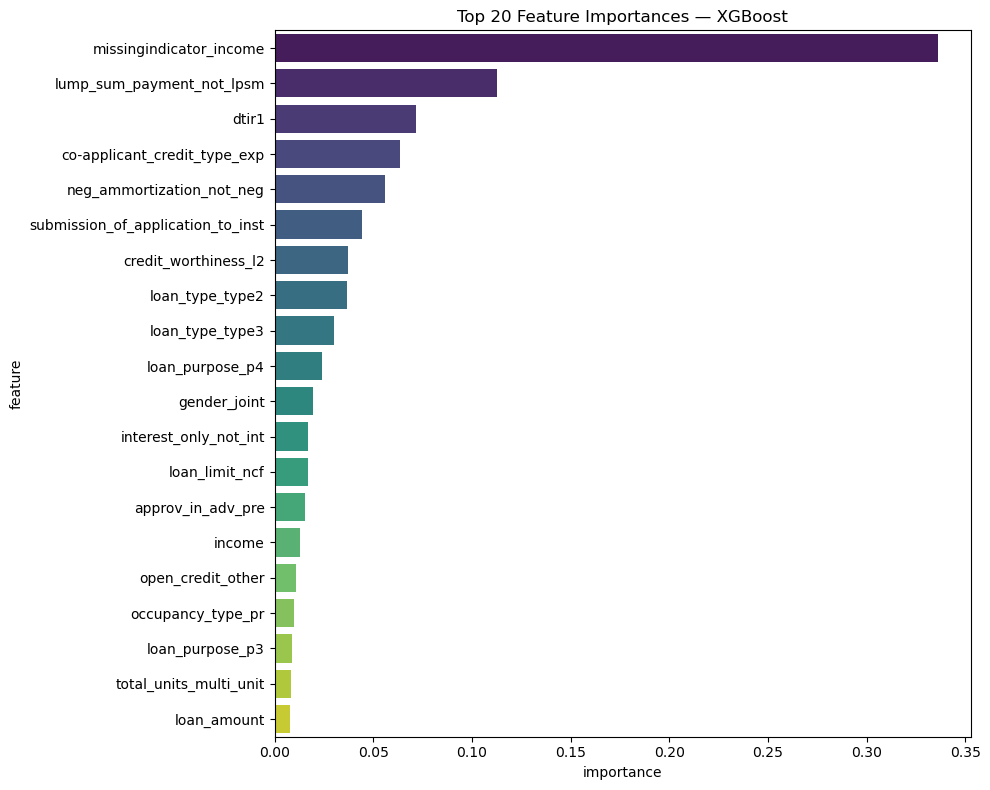

                          feature  importance
          missingindicator_income    0.336219
        lump_sum_payment_not_lpsm    0.112623
                            dtir1    0.071862
     co-applicant_credit_type_exp    0.063814
        neg_ammortization_not_neg    0.056042
submission_of_application_to_inst    0.044375
             credit_worthiness_l2    0.037105
                  loan_type_type2    0.036936
                  loan_type_type3    0.029957
                  loan_purpose_p4    0.023911
                     gender_joint    0.019595
            interest_only_not_int    0.016960
                   loan_limit_ncf    0.016802
                approv_in_adv_pre    0.015456
                           income    0.012723
                open_credit_other    0.010666
                occupancy_type_pr    0.009949
                  loan_purpose_p3    0.008835
           total_units_multi_unit    0.008105
                      loan_amount    0.007922


In [15]:
xgb_model    = best_pipeline.named_steps['model']
X_trans      = best_pipeline[:-1].transform(X_train)
feature_names = X_trans.columns.tolist()

importance_df = pd.DataFrame({
    'feature'    : feature_names,
    'importance' : xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='viridis')
plt.title('Top 20 Feature Importances — XGBoost')
plt.tight_layout()
plt.show()

print(importance_df.head(20).to_string(index=False))

## 16. Save Pipeline

In [16]:
import joblib
joblib.dump(best_pipeline, 'loan_default_pipeline.pkl')
print('Pipeline saved to loan_default_pipeline.pkl')

Pipeline saved to loan_default_pipeline.pkl
